# First Neural Network on Images

This notebook trains an MLP classifier on Fashion-MNIST, demonstrating the complete training pipeline: data loading, preprocessing, model definition, training with validation, and evaluation.

In [2]:
import torch
from torch import nn
from torch import optim
from torchvision import transforms, datasets
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.5.1
Using device: cpu


In [2]:
# (device configuration is in the cell above)

# Let's start by loading the training set of fashion MNIST. PyTorch has a number of functions to load popular datasets in 'torchvision.datasets'. The training set contains 60,000 grayscale images, each 28x28 pixels.

In [6]:
#base com 10 classes de bolsas/blusas com imagens pequenas 
trainset = datasets.FashionMNIST(root='./images', train=True, transform=None, download=True)

100%|██████████| 26.4M/26.4M [10:17<00:00, 42.8kB/s]


Extracting ./images/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./images/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:02<00:00, 11.4kB/s]


Extracting ./images/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./images/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [01:51<00:00, 39.7kB/s]


Extracting ./images/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./images/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:01<00:00, 3.57kB/s]

Extracting ./images/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./images/FashionMNIST/raw



In [7]:
# Normalization: (0.5, 0.5) maps pixel values from [0,1] to [-1,1].
# This is a common simplification. For more accurate normalization,
# Fashion-MNIST has mean ~0.2860 and std ~0.3530.

FMNIST_MEAN = (0.5,)
FMNIST_STD  = (0.5,)

prep = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(FMNIST_MEAN, FMNIST_STD)   
])

class FMNistDataset(Dataset):
    def __init__(self, dataset, transform=None): 
        self.dataset   = dataset
        self.transform = transform

    def __getitem__(self, index):
        img, target = self.dataset[index]
        return self.transform(img), target

    def __len__(self):
        return len(self.dataset)

Images are 28x28x1


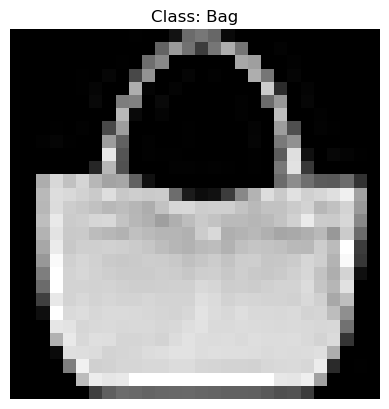

In [8]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

dataset   = FMNistDataset(trainset, prep)
(image, target) = dataset[100]
nchannels = image.shape[0]
height    = image.shape[1]
width     = image.shape[2]
print(f"Images are {width}x{height}x{nchannels}")

# Undo normalization for visualization
mean = torch.tensor(FMNIST_MEAN).view(1, 1, 1)
std  = torch.tensor(FMNIST_STD).view(1, 1, 1)
image_vis = (image * std + mean).clamp(0, 1)
image_vis = image_vis.squeeze(0).numpy()  # grayscale: remove channel dim

plt.imshow(image_vis, cmap='gray')
plt.title(f"Class: {class_names[target]}")
plt.axis('off')
plt.show()

## Let's split our training set into training, validation, and test sets by creating one data loader for each.

In [9]:
indices      = list(range(len(dataset)))
train_sample = SubsetRandomSampler(indices[:30000])
valid_sample = SubsetRandomSampler(indices[30000:45000])
test_sample  = SubsetRandomSampler(indices[45000:])
trainloader  = DataLoader(dataset,sampler=train_sample,batch_size=64)
validloader  = DataLoader(dataset,sampler=valid_sample,batch_size=64)
testloader   = DataLoader(dataset,sampler=test_sample,batch_size=64)

# Create your first NN on images

Since this categorical image classification problem is simple, you may start by flattening the input images into feature vectors to be the input of an MLP classifier.

In [10]:
class FMNistNet(nn.Module):

    def __init__(self, input_shape, nclasses=10):
        super().__init__()
        #rede simples
        # MLP classifier: flatten -> dense layers with dropout
        self.classifier = nn.Sequential(
            nn.Linear(in_features=input_shape[1]*input_shape[2], out_features=300, bias=True),
            nn.ReLU(), #to pegando so camada linear, vetorizando 28*28 
            nn.Dropout(0.25),
            nn.Linear(in_features=300, out_features=100, bias=True),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(100, nclasses)
        )

        self.weights_init()

    def forward(self, x):
        # Flatten image into a vector (keep batch dimension)
        x = torch.flatten(x, start_dim=1) #vetoriza todas as imagens do batch
        y = self.classifier(x)
        return y
  #inicializando os pesos com havier
    def weights_init(self):
        for x in self.modules():
            if isinstance(x, nn.Linear):
                torch.nn.init.xavier_uniform_(x.weight.data)
                if (x.bias is not None): 
                    x.bias.data.zero_()

# Build the model and define criterion and optimizer

In [11]:
# Create loss function once (not per batch)
#funcao de perda, entropia cruzada para as 10 classes
ce_loss = nn.CrossEntropyLoss()

def Criterion(preds, targets):
    loss        = ce_loss(preds, targets.long()) 
    pred_labels = torch.argmax(preds, dim=1)
    acc         = torch.sum(pred_labels == targets.data).item() / pred_labels.size(0)
    return loss, acc
#otimizar adam    
# Create the model with cross entropy loss and Adam optimizer
model     = FMNistNet((nchannels, height, width)).to(device)
print(model)
criterion = Criterion
optimizer = optim.Adam(model.parameters(), lr=1e-3)

FMNistNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=300, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.25, inplace=False)
    (6): Linear(in_features=100, out_features=10, bias=True)
  )
)


# Train the model and report the results 

In [12]:
#loop de treino 
def train_batch(model, data, optimizer, criterion, device):
    model.train()
    ims, targets = data #pra cada btach divide em imagem e targe e coloca no device no caso do exemplo do professor é a gpu
    ims     = ims.to(device)
    targets = targets.to(device)
    
    optimizer.zero_grad()          # 1. reset gradients
    preds      = model(ims)        # 2. forward pass
    loss, acc  = criterion(preds, targets)  # 3. compute loss
    loss.backward()                # 4. backward pass
    optimizer.step()               # 5. update weights #calcula os gradientes e atualiza os peses
    return loss.item(), acc

#na validacao o gradiente ta zerado pra nao ficar acumulando na memoria
@torch.no_grad()
def validate_batch(model, data, criterion, device):
    model.eval()
    ims, targets = data
    ims     = ims.to(device)
    targets = targets.to(device)
    preds      = model(ims)
    loss, acc  = criterion(preds, targets)
    return loss.item(), acc

In [13]:
n_epochs = 40

# Track metrics
trn_losses, trn_accs = [], []
val_losses, val_accs = [], []

#pra cada epoca eu passo o for em dataloader, cada passo ele pega um batch do dataloader e joga em data
for epoch in range(n_epochs):
    # --- Training ---
    epoch_trn_loss, epoch_trn_acc, n_batches = 0, 0, 0
    for data in trainloader:
        loss, acc = train_batch(model, data, optimizer, criterion, device)
        epoch_trn_loss += loss
        epoch_trn_acc  += acc
        n_batches += 1
    trn_losses.append(epoch_trn_loss / n_batches)
    trn_accs.append(epoch_trn_acc / n_batches)

    # --- Validation ---
    epoch_val_loss, epoch_val_acc, n_batches = 0, 0, 0
    for data in validloader:
        loss, acc = validate_batch(model, data, criterion, device)
        epoch_val_loss += loss
        epoch_val_acc  += acc
        n_batches += 1
    val_losses.append(epoch_val_loss / n_batches)
    val_accs.append(epoch_val_acc / n_batches)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} — "
              f"Train loss: {trn_losses[-1]:.4f}, acc: {trn_accs[-1]:.4f} | "
              f"Val loss: {val_losses[-1]:.4f}, acc: {val_accs[-1]:.4f}")

Epoch  10/40 — Train loss: 0.3297, acc: 0.8779 | Val loss: 0.3428, acc: 0.8786
Epoch  20/40 — Train loss: 0.2662, acc: 0.8990 | Val loss: 0.3289, acc: 0.8858
Epoch  30/40 — Train loss: 0.2265, acc: 0.9129 | Val loss: 0.3435, acc: 0.8912
Epoch  40/40 — Train loss: 0.2022, acc: 0.9235 | Val loss: 0.3643, acc: 0.8870


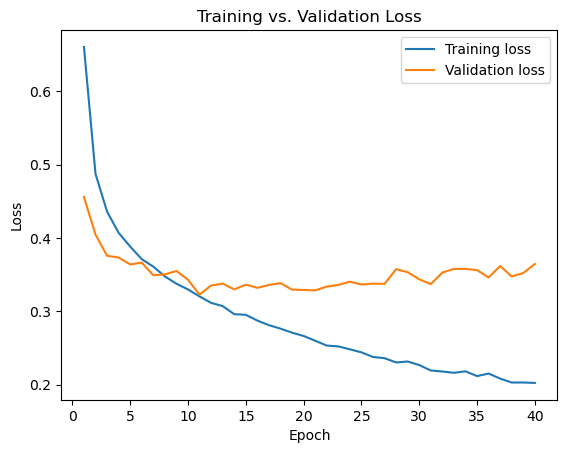

In [14]:
# resultado rodando no meu pc
epochs = range(1, n_epochs + 1)
plt.plot(epochs, trn_losses, label='Training loss')
plt.plot(epochs, val_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs. Validation Loss')
plt.show()

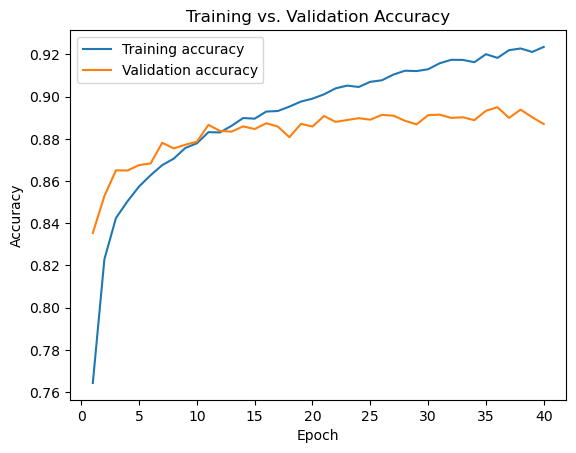

In [15]:
# resultado rodando no meu pc
plt.plot(epochs, trn_accs, label='Training accuracy')
plt.plot(epochs, val_accs, label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs. Validation Accuracy')
plt.show()

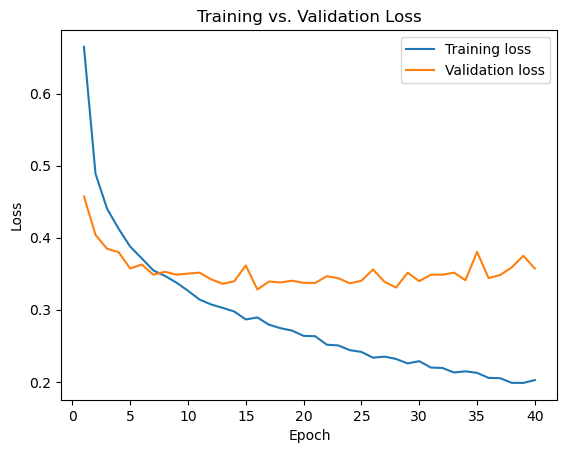

In [ ]:
# resultado do professor na aula
epochs = range(1, n_epochs + 1)
plt.plot(epochs, trn_losses, label='Training loss')
plt.plot(epochs, val_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs. Validation Loss')
plt.show()

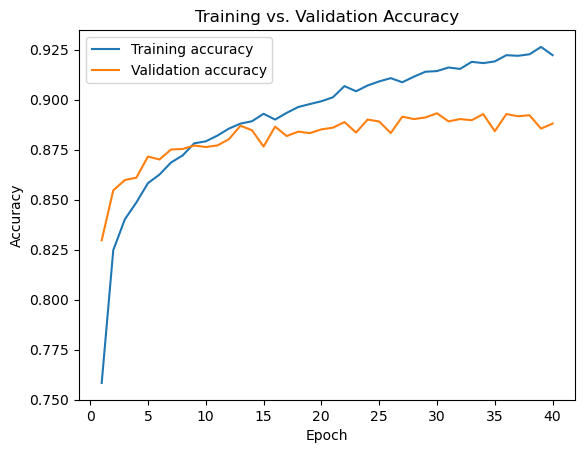

In [ ]:
# resultado do professor na aula
plt.plot(epochs, trn_accs, label='Training accuracy')
plt.plot(epochs, val_accs, label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs. Validation Accuracy')
plt.show()

# Evaluate the NN on the test set

In [ ]:
#resultado professor tinha dado proximo
mean_loss, mean_acc, n_batches = 0, 0, 0
for data in testloader:
    loss, acc  = validate_batch(model, data, criterion, device)
    mean_loss += loss
    mean_acc  += acc
    n_batches += 1
    
mean_loss /= n_batches
mean_acc  /= n_batches
print(f'Test loss: {mean_loss:.4f}, Test acc: {mean_acc:.4f}')

Test loss: 0.3848, Test acc: 0.8865


# Save the model

In [14]:
torch.save(model.to('cpu').state_dict(), "FMNistMLP.pth")

## Exercise

Observe the training and validation curves above. Is the model underfitting or overfitting?

Try the following modifications and observe the effect on the curves:
- Change the **learning rate** (e.g., try `1e-2`, `1e-4`).
- Change the **network architecture** (add/remove layers, change the number of neurons).
- Change the **dropout probability** (e.g., try `0.1`, `0.5`).
- Change the **batch size** and the **number of epochs**.
- Change the **train/validation/test split** proportions.

The goal is to find a configuration that achieves high accuracy on both training and validation sets without a large gap between them.

### Underfitting ou Overfitting?

Comparar as curvas de treino e validação acima:

| Situação | Train acc | Val acc | Gap (train−val) | Diagnóstico |
|---|---|---|---|---|
| **Underfitting** | baixa | baixa | pequeno | modelo com poucos parâmetros ou epochs |
| **Overfitting**  | alta  | baixa | **grande** | modelo memorizou o treino; não generaliza |
| **Bom ajuste**   | alta  | alta  | pequeno | modelo generaliza bem |

> **Configuração base:** `lr=1e-3`, `hidden=[300,100]`, `dropout=0.25`, `batch=64`, `epochs=40`, `split=50/25/25%`

In [ ]:
# teste de rede flexível

class FlexMLP(nn.Module):
    """MLP configurável: número variável de camadas ocultas e dropout."""

    def __init__(self, hidden_sizes=[300, 100], dropout_p=0.25, nclasses=10):
        super().__init__()
        layers, in_dim = [], 784          # Fashion-MNIST: 28×28 = 784
        for h in hidden_sizes:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout_p)]
            in_dim = h
        layers.append(nn.Linear(in_dim, nclasses))
        self.classifier = nn.Sequential(*layers)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    m.bias.data.zero_()

    def forward(self, x):
        return self.classifier(torch.flatten(x, start_dim=1))


def run_experiment(lr=1e-3, dropout_p=0.25, batch_size=64, n_epochs=15,
                   hidden_sizes=[300, 100], train_end=30000, valid_end=45000):
    """Treina e avalia um FlexMLP com os hiperparâmetros dados.

    Retorna: (trn_losses, trn_accs, val_losses, val_accs, test_acc, model)
    """
    torch.manual_seed(42)

    tr_s = SubsetRandomSampler(indices[:train_end])
    va_s = SubsetRandomSampler(indices[train_end:valid_end])
    te_s = SubsetRandomSampler(indices[valid_end:])
    trl  = DataLoader(dataset, sampler=tr_s, batch_size=batch_size)
    val  = DataLoader(dataset, sampler=va_s, batch_size=batch_size)
    tel  = DataLoader(dataset, sampler=te_s, batch_size=batch_size)

    m   = FlexMLP(hidden_sizes=hidden_sizes, dropout_p=dropout_p).to(device)
    opt = optim.Adam(m.parameters(), lr=lr)

    trn_l, trn_a, val_l, val_a = [], [], [], []
    for _ in range(n_epochs):
        tl, ta, nb = 0, 0, 0
        for data in trl:
            l, a = train_batch(m, data, opt, criterion, device)
            tl += l; ta += a; nb += 1
        trn_l.append(tl / nb); trn_a.append(ta / nb)

        vl, va_acc, nb = 0, 0, 0
        for data in val:
            l, a = validate_batch(m, data, criterion, device)
            vl += l; va_acc += a; nb += 1
        val_l.append(vl / nb); val_a.append(va_acc / nb)

    tacc, nb = 0, 0
    for data in tel:
        _, a = validate_batch(m, data, criterion, device)
        tacc += a; nb += 1

    return trn_l, trn_a, val_l, val_a, tacc / nb, m


n_base = sum(p.numel() for p in FlexMLP().parameters())
print(f"FlexMLP e run_experiment prontos!")
print(f"Parâmetros do modelo base [300, 100]: {n_base:,}")

FlexMLP e run_experiment prontos!
Parâmetros do modelo base [300, 100]: 266,610


## teste 1 — Learning Rate (`1e-4`, `1e-3`, `1e-2`)

**Hipótese:**
- `1e-4` → convergência lenta, pode não atingir bom desempenho em 15 épocas
- `1e-3` → patamar padrão do Adam, bom equilíbrio velocidade/estabilidade  
- `1e-2` → passos grandes, pode oscilar ou divergir

lr=1e-04 ... val_acc=0.8805  test_acc=0.8746  gap=0.0009
lr=1e-03 ... val_acc=0.8846  test_acc=0.8795  gap=0.0049
lr=1e-02 ... val_acc=0.8358  test_acc=0.8265  gap=-0.0539


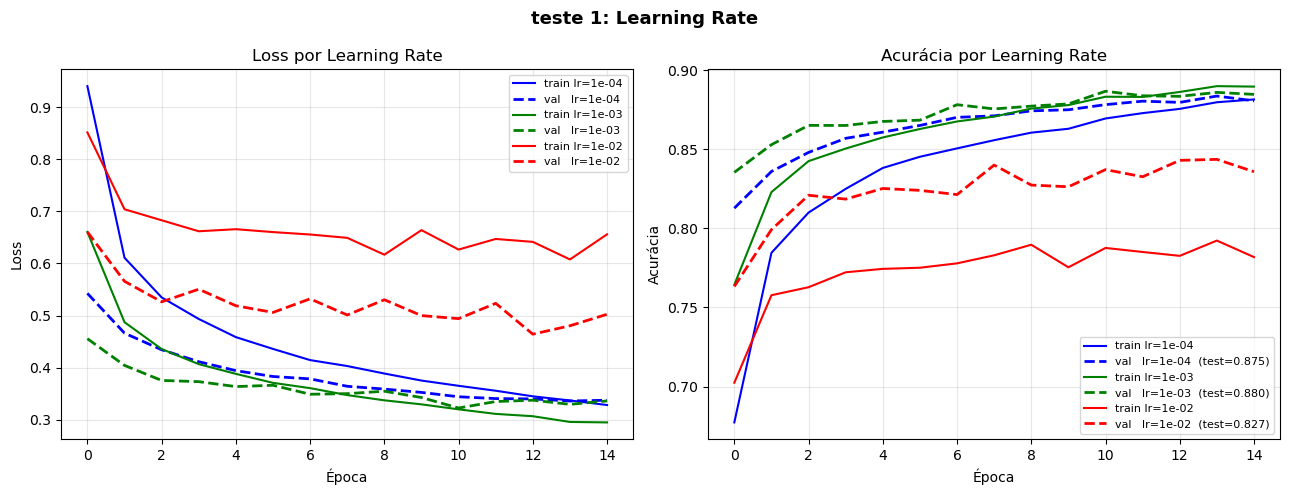

In [19]:
lrs         = [1e-4, 1e-3, 1e-2]
colors_lr   = ['blue', 'green', 'red']
results_lr  = {}

for lr in lrs:
    print(f"lr={lr:.0e} ...", end=" ", flush=True)
    trn_l, trn_a, val_l, val_a, test_acc, _ = run_experiment(lr=lr)
    results_lr[lr] = (trn_l, trn_a, val_l, val_a, test_acc)
    print(f"val_acc={val_a[-1]:.4f}  test_acc={test_acc:.4f}  gap={trn_a[-1]-val_a[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for (lr, res), col in zip(results_lr.items(), colors_lr):
    trn_l, trn_a, val_l, val_a, test_acc = res
    axes[0].plot(trn_l, '-',  color=col, lw=1.5, label=f'train lr={lr:.0e}')
    axes[0].plot(val_l, '--', color=col, lw=2.0, label=f'val   lr={lr:.0e}')
    axes[1].plot(trn_a, '-',  color=col, lw=1.5, label=f'train lr={lr:.0e}')
    axes[1].plot(val_a, '--', color=col, lw=2.0,
                 label=f'val   lr={lr:.0e}  (test={test_acc:.3f})')

for ax, title, ylabel in zip(axes, ['Loss por Learning Rate', 'Acurácia por Learning Rate'],
                                    ['Loss', 'Acurácia']):
    ax.set_xlabel('Época'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('teste 1: Learning Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## teste 2 — Arquitetura da rede (adicionar/remover camadas e neurônios)

**Hipótese:**
- Rede rasa `[128]` → underfitting (pouca capacidade)
- Base `[300, 100]` → configuração original
- Funda `[512, 256, 128]` → mais capacidade; pode overfittar se sem regularização
- Larga `[1024, 512]` → muitos parâmetros; overfitting provável sem dropout forte

In [20]:
archs = {
    'Rasa  [128]'         : [128],
    'Base  [300,100]'     : [300, 100],
    'Funda [512,256,128]' : [512, 256, 128],
    'Larga [1024,512]'    : [1024, 512],
}
colors_arch  = ['red', 'blue', 'green', 'orange']
results_arch = {}

for name, hidden in archs.items():
    n_par = sum(p.numel() for p in FlexMLP(hidden_sizes=hidden).parameters())
    print(f"{name}  ({n_par:,} params) ...", end=" ", flush=True)
    trn_l, trn_a, val_l, val_a, test_acc, _ = run_experiment(hidden_sizes=hidden)
    results_arch[name] = (trn_l, trn_a, val_l, val_a, test_acc)
    print(f"val={val_a[-1]:.4f}  test={test_acc:.4f}  gap={trn_a[-1]-val_a[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for (name, res), col in zip(results_arch.items(), colors_arch):
    trn_l, trn_a, val_l, val_a, test_acc = res
    axes[0].plot(trn_l, '-',  color=col, lw=1.5, label=f'train {name}')
    axes[0].plot(val_l, '--', color=col, lw=2.0, label=f'val   {name}')
    axes[1].plot(trn_a, '-',  color=col, lw=1.5, label=f'train {name}')
    axes[1].plot(val_a, '--', color=col, lw=2.0,
                 label=f'val   {name}  (test={test_acc:.3f})')

for ax, title, ylabel in zip(axes, ['Loss por Arquitetura', 'Acurácia por Arquitetura'],
                                    ['Loss', 'Acurácia']):
    ax.set_xlabel('Época'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('teste 2: Arquitetura', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Rasa  [128]  (101,770 params) ... val=0.8822  test=0.8749  gap=0.0138
Base  [300,100]  (266,610 params) ... 

KeyboardInterrupt: 

## teste 3 — Probabilidade de Dropout (`0.0`, `0.1`, `0.25`, `0.5`)

**Dropout** desativa aleatoriamente neurônios durante o treino, forçando a rede a aprender representações mais robustas (regularização).

**Hipótese:**
- `0.0` (sem dropout) → overfitting: grande gap entre treino e validação
- `0.1` → pouca regularização
- `0.25` → configuração base, bom equilíbrio
- `0.5` → regularização forte; pode subajustar se a rede for pequena

In [ ]:
dropouts     = [0.0, 0.1, 0.25, 0.5]
colors_drop  = ['purple', 'blue', 'green', 'red']
results_drop = {}

for dp in dropouts:
    print(f"dropout={dp} ...", end=" ", flush=True)
    trn_l, trn_a, val_l, val_a, test_acc, _ = run_experiment(dropout_p=dp)
    results_drop[dp] = (trn_l, trn_a, val_l, val_a, test_acc)
    print(f"val={val_a[-1]:.4f}  test={test_acc:.4f}  gap={trn_a[-1]-val_a[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for (dp, res), col in zip(results_drop.items(), colors_drop):
    trn_l, trn_a, val_l, val_a, test_acc = res
    # pra acurácia: mostrar treino e val para ver o gap
    axes[0].plot(trn_a, '-',  color=col, lw=1.5, label=f'train p={dp}')
    axes[0].plot(val_a, '--', color=col, lw=2.0,
                 label=f'val   p={dp}  (test={test_acc:.3f})')
    axes[1].plot(val_l, '-', color=col, lw=2.0, label=f'val loss  p={dp}')

axes[0].set_title('Acurácia: quanto maior o gap → mais overfitting')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Acurácia')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].set_title('Val Loss por Probabilidade de Dropout')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Val Loss')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle('teste 3: Dropout', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## teste 4 — Batch Size e Número de Épocas

**Batch size** controla quantas amostras são usadas por atualização de pesos:
- **Pequeno (32)** → mais ruído, melhor generalização, mais passos por época, mais lento
- **Grande (256)** → mais estável, convergência mais rápida por época, mas menos passos

**Épocas** controlam por quanto tempo a rede é treinada:
- Poucas épocas → underfitting
- Muitas épocas → tendência ao overfitting

In [ ]:
batch_sizes = [32, 64, 128, 256]
colors_bs   = ['red', 'blue', 'green', 'orange']
results_bs  = {}

for bs in batch_sizes:
    print(f"batch_size={bs:3d} ...", end=" ", flush=True)
    trn_l, trn_a, val_l, val_a, test_acc, _ = run_experiment(batch_size=bs)
    results_bs[bs] = (trn_l, trn_a, val_l, val_a, test_acc)
    print(f"val={val_a[-1]:.4f}  test={test_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for (bs, res), col in zip(results_bs.items(), colors_bs):
    trn_l, trn_a, val_l, val_a, test_acc = res
    axes[0].plot(val_l, '-', color=col, lw=2, label=f'val loss  bs={bs}')
    axes[1].plot(val_a, '-', color=col, lw=2,
                 label=f'val acc   bs={bs}  (test={test_acc:.3f})')

axes[0].set_title('Val Loss por Batch Size')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].set_title('Val Acurácia por Batch Size')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Acurácia')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('teste 4: Batch Size\n'
             'batch pequeno = mais ruído por passo, batch grande = gradiente mais estável',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ver efeito do número de épocas (batch fixo = 64)
print("\nEfeito do número de épocas:")
n_epochs_list = [5, 10, 20, 40]
colors_ep     = ['red', 'orange', 'green', 'blue']
results_ep    = {}

for ne in n_epochs_list:
    print(f"epochs={ne:2d} ...", end=" ", flush=True)
    trn_l, trn_a, val_l, val_a, test_acc, _ = run_experiment(n_epochs=ne)
    results_ep[ne] = (trn_l, trn_a, val_l, val_a, test_acc)
    print(f"val={val_a[-1]:.4f}  test={test_acc:.4f}  gap={trn_a[-1]-val_a[-1]:.4f}")

fig2, ax = plt.subplots(figsize=(8, 5))
for (ne, res), col in zip(results_ep.items(), colors_ep):
    trn_l, trn_a, val_l, val_a, test_acc = res
    ax.plot(trn_a, '-',  color=col, lw=1.5, label=f'train epochs={ne}')
    ax.plot(val_a, '--', color=col, lw=2.0,
            label=f'val   epochs={ne}  (test={test_acc:.3f})')

ax.set_title('Efeito do Número de Épocas')
ax.set_xlabel('Época'); ax.set_ylabel('Acurácia')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## teste 5 — Proporções do Split Train/Val/Test

O dataset tem 60.000 amostras. Testamos:
- **25/37/38%** (15k / 22k / 23k): pouco treino, avaliação robusta
- **50/25/25%** (30k / 15k / 15k): configuração base do notebook
- **70/15/15%** (42k /  9k /  9k): mais dados de treino, menor conjunto de avaliação

**Hipótese:** mais dados de treino → melhor generalização, mas o conjunto de teste menor torna a estimativa da acurácia final menos confiável.

In [ ]:
# train_end = fim do conjunto de treino; 
# valid_end = fim do conjunto de validação
splits = {
    '25/37/38%\n(15k train)': (15000, 37000),
    '50/25/25%\n(30k train)': (30000, 45000),
    '70/15/15%\n(42k train)': (42000, 51000),
}
colors_sp  = ['red', 'blue', 'green']
results_sp = {}

for name, (te, ve) in splits.items():
    flat_name = name.replace('\n', ' ')
    print(f"Split {flat_name} ...", end=" ", flush=True)
    trn_l, trn_a, val_l, val_a, test_acc, _ = run_experiment(train_end=te, valid_end=ve)
    results_sp[name] = (trn_l, trn_a, val_l, val_a, test_acc)
    print(f"val={val_a[-1]:.4f}  test={test_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
test_results = []

for (name, res), col in zip(results_sp.items(), colors_sp):
    trn_l, trn_a, val_l, val_a, test_acc = res
    label_short = name.split('\n')[0]
    axes[0].plot(trn_a, '-',  color=col, lw=1.5, label=f'train {label_short}')
    axes[0].plot(val_a, '--', color=col, lw=2.0, label=f'val   {label_short}')
    test_results.append((name, test_acc, col))

# grafico com resultados
names_sp = [t[0] for t in test_results]
accs_sp  = [t[1] for t in test_results]
cols_sp  = [t[2] for t in test_results]
bars = axes[1].bar(range(len(names_sp)), accs_sp, color=cols_sp, alpha=0.8)
axes[1].set_xticks(range(len(names_sp)))
axes[1].set_xticklabels(names_sp, fontsize=9)
axes[1].set_ylim(min(accs_sp) - 0.03, max(accs_sp) + 0.04)
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Acurácia no Teste por Proporção do Split')
axes[1].grid(True, alpha=0.3, axis='y')
for i, acc in enumerate(accs_sp):
    axes[1].text(i, acc + 0.005, f'{acc:.4f}', ha='center', fontsize=10)

axes[0].set_title('Acurácia treino/val por Split')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Acurácia')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

plt.suptitle('teste 5: Proporção Train/Val/Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Treino Completo

Com base nos testes acima, testei treinar por mais épocas para verificar se o modelo consegue **alta acurácia com gap pequeno** entre treino e validação.

In [ ]:
# configuração escolhida com base nos testes:
#   - lr=1e-3          : melhor equilíbrio velocidade/estabilidade (Exp 1)
#   - hidden=[512,256,128]: mais capacidade sem overfitting excessivo (Exp 2)
#   - dropout_p=0.25   : boa regularização para essa arquitetura (Exp 3)
#   - batch_size=64    : equilíbrio ruído/estabilidade (Exp 4)
#   - train_end=42000  : mais dados de treino (70%) (Exp 5)
#   - n_epochs=50      : treino mais longo para aproveitar a capacidade da rede

best_config = dict(
    lr           = 1e-3,
    hidden_sizes = [512, 256, 128],
    dropout_p    = 0.25,
    batch_size   = 64,
    n_epochs     = 50,
    train_end    = 42000,
    valid_end    = 51000,
)

n_par = sum(p.numel() for p in FlexMLP(best_config['hidden_sizes']).parameters())
print(f"melhor config")
for k, v in best_config.items():
    print(f"  {k:<15}: {v}")
print(f"  {'params':<15}: {n_par:,}")
print()

trn_l, trn_a, val_l, val_a, test_acc, best_model = run_experiment(**best_config)

print(f"\n{'='*40}")
print(f"  Train acc  final  : {trn_a[-1]:.4f}")
print(f"  Val   acc  final  : {val_a[-1]:.4f}")
print(f"  Test  acc         : {test_acc:.4f}")
print(f"  Gap (train - val) : {trn_a[-1] - val_a[-1]:.4f}")
print(f"{'='*40}")

ep = range(1, best_config['n_epochs'] + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(ep, trn_l, label='Train loss')
axes[0].plot(ep, val_l, '--', label='Val loss')
axes[0].set_title('melhor config — Loss')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, trn_a, label='Train acc')
axes[1].plot(ep, val_a, '--', label='Val acc')
axes[1].axhline(test_acc, color='red', linestyle=':', lw=2,
                label=f'Test acc = {test_acc:.4f}')
axes[1].set_title('melhor config — Acurácia')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Acurácia')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

cfg_str = (f"lr={best_config['lr']}  hidden={best_config['hidden_sizes']}  "
           f"dropout={best_config['dropout_p']}  batch={best_config['batch_size']}  "
           f"epochs={best_config['n_epochs']}  split=70/15/15%")
plt.suptitle(f"melhor config\n{cfg_str}", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Ver a matriz de confusão

In [ ]:
class_names_local = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
                     "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# conjunto de teste correspondente à best_config
te_s_best = SubsetRandomSampler(indices[best_config['valid_end']:])
tel_best  = DataLoader(dataset, sampler=te_s_best, batch_size=256)

all_preds, all_labels = [], []
best_model.eval()
with torch.no_grad():
    for ims, targets in tel_best:
        ims = ims.to(device)
        preds = best_model(ims).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(targets.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# montar matriz de confusão
n_cls = 10
cm = np.zeros((n_cls, n_cls), dtype=int)
for t, p in zip(all_labels, all_preds):
    cm[t, p] += 1

per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# heatmap
im = axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=axes[0])
ticks = range(n_cls)
axes[0].set_xticks(ticks)
axes[0].set_xticklabels(class_names_local, rotation=45, ha='right', fontsize=8)
axes[0].set_yticks(ticks)
axes[0].set_yticklabels(class_names_local, fontsize=8)
axes[0].set_xlabel('Predição'); axes[0].set_ylabel('Classe verdadeira')
axes[0].set_title('Matriz de Confusão')
thresh = cm.max() / 2
for i in range(n_cls):
    for j in range(n_cls):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=7,
                     color='white' if cm[i, j] > thresh else 'black')

# acc por classe
axes[1].barh(class_names_local, per_class_acc, color='steelblue', alpha=0.8)
axes[1].axvline(per_class_acc.mean(), color='red', linestyle='--', lw=2,
                label=f'Média: {per_class_acc.mean():.3f}')
axes[1].set_xlim(0, 1.08)
axes[1].set_xlabel('Acurácia'); axes[1].set_title('Acurácia por Classe')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='x')
for i, acc in enumerate(per_class_acc):
    axes[1].text(acc + 0.01, i, f'{acc:.3f}', va='center', fontsize=9)

plt.suptitle('análise por classe — melhor modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

sorted_idx = np.argsort(per_class_acc)
print("classes mais difíceis (menor acurácia):")
for i in sorted_idx[:3]:
    print(f"  {class_names_local[i]:15s}: {per_class_acc[i]:.4f}")
print("classes mais fáceis (maior acurácia):")
for i in sorted_idx[-3:][::-1]:
    print(f"  {class_names_local[i]:15s}: {per_class_acc[i]:.4f}")
print(f"\nacurácia média no teste (por classe): {per_class_acc.mean():.4f}")